# Лабораторная работа: обработка изображений с использованием Python


## 1. Загрузка цветного изображения

Сначала загрузим цветное изображение. Форматы могут быть `.jpg`, `.jpeg` или `.png`.

Используем библиотеку `cv2` для чтения изображения. 

Изображение успешно загружено: (507, 338, 3)


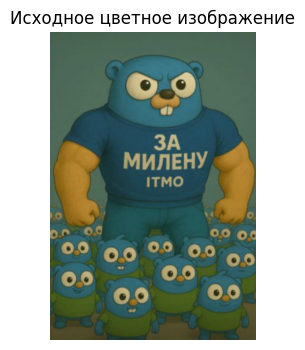

In [5]:
# Импорт необходимых библиотек
import numpy as np
import cv2 # OpenCV для работы с изображениями
import matplotlib.pyplot as plt

# Загрузка изображения (замените 'image.jpg' на ваш файл)
image_path = 'Za_Milenu.jpg'  # Путь к изображению

img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError(f"Файл не найден: {image_path}")
# cv2 читает изображение в BGR-формате по умолчанию
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Преобразуем в RGB для отображения
print("Изображение успешно загружено:", img.shape)
# Отобразим исходное цветное изображение
plt.figure(figsize=(6,4))
plt.imshow(img)
plt.axis('off')
plt.title('Исходное цветное изображение')
plt.show()


## 2. Представление изображения как функции $f: \mathbb{R}^2 \to \mathbb{R}^3$ и разделение на каналы

Цветное изображение можно рассматривать как дискретную функцию $f(x, y) = (R, G, B)$, которая отображает каждую точку координат $(x,y)$ в трехмерный цветовой вектор. Выделим отдельные цветовые каналы: красный (R), зеленый (G), синий (B).


In [6]:
# Разделение на каналы R, G, B
R = img[:, :, 0].copy()
G = img[:, :, 1].copy()
B = img[:, :, 2].copy()
print(f"Формы каналов R, G, B: {R.shape}, {G.shape}, {B.shape}")

# Для наглядности объединим каналы по парам: (R,G), (G,B), (R,B)
RG = np.stack((R, G, np.zeros_like(R)), axis=2)  # оставляем R,G, зануляем B
GB = np.stack((np.zeros_like(R), G, B), axis=2)
RB = np.stack((R, np.zeros_like(R), B), axis=2)


Формы каналов R, G, B: (507, 338), (507, 338), (507, 338)


## 3. Отображение отдельных и парных каналов

Визуализируем каждый канал по отдельности (отдельный оттенок серого) и три комбинации RGB: RG (синий канал=0), GB (красный канал=0), RB (зеленый канал=0). Это позволяет увидеть вклад каждого цветового канала в общее изображение.


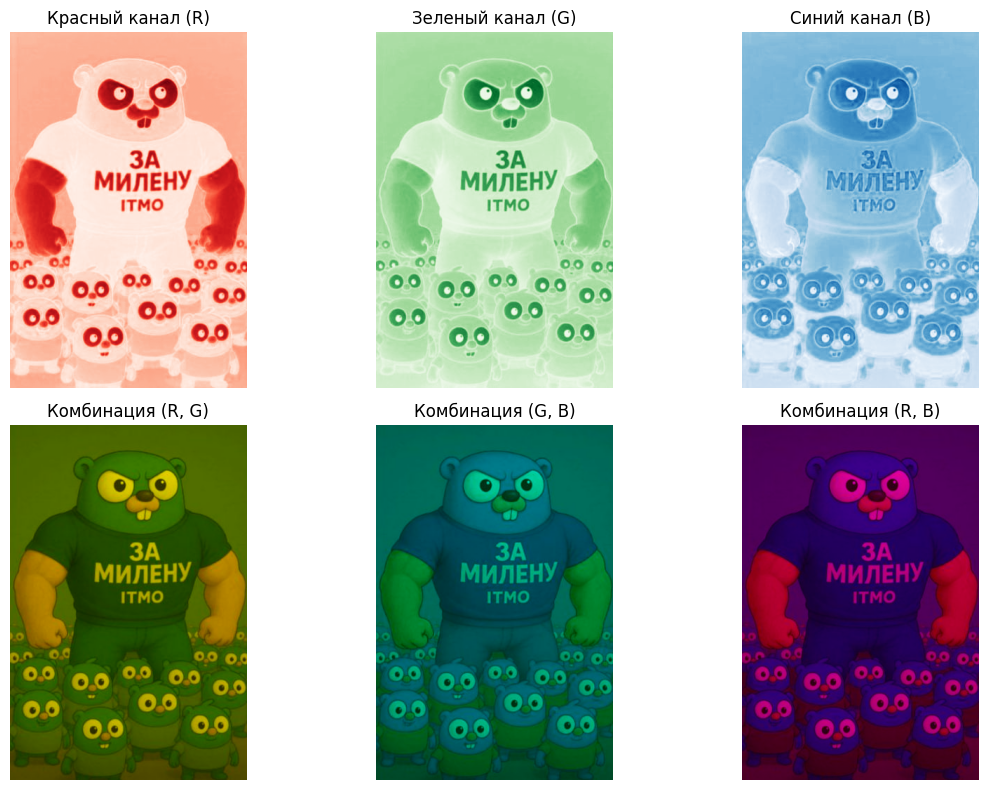

In [7]:
# Настройка отображения
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

# Отображение отдельных каналов в оттенках соответствующих цветов
axes[0].imshow(R, cmap='Reds')
axes[0].set_title('Красный канал (R)')
axes[0].axis('off')
axes[1].imshow(G, cmap='Greens')
axes[1].set_title('Зеленый канал (G)')
axes[1].axis('off')
axes[2].imshow(B, cmap='Blues')
axes[2].set_title('Синий канал (B)')
axes[2].axis('off')

# Отображение комбинированных каналов (две пары + один канал нулевой)
axes[3].imshow(RG)
axes[3].set_title('Комбинация (R, G)')
axes[3].axis('off')
axes[4].imshow(GB)
axes[4].set_title('Комбинация (G, B)')
axes[4].axis('off')
axes[5].imshow(RB)
axes[5].set_title('Комбинация (R, B)')
axes[5].axis('off')

plt.tight_layout()
plt.show()


## 4. Преобразование изображения в оттенки серого

Преобразуем цветное изображение в черно-белое. Один из стандартных методов – взвешенная сумма каналов: $Gray = 0.299R + 0.587G + 0.114B$ (такая формула используется в Y-компоненте цветовых пространств). Этот метод учитывает восприятие глазом яркости разных цветов.


Сохраненная форма серого изображения: (507, 338)


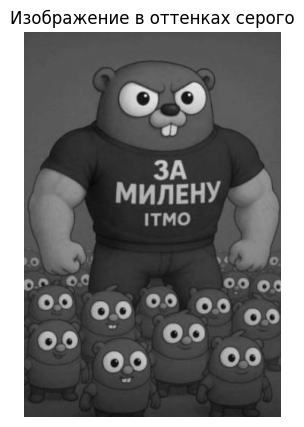

In [8]:
# Функция для преобразования в оттенки серого по взвешенной формуле
def rgb2gray(image_rgb):
    r, g, b = image_rgb[:,:,0], image_rgb[:,:,1], image_rgb[:,:,2]
    gray = (0.299 * r + 0.587 * g + 0.114 * b).astype(np.uint8)
    return gray

gray = rgb2gray(img)
print(f"Сохраненная форма серого изображения: {gray.shape}")

plt.figure(figsize=(5,5))
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.title('Изображение в оттенках серого')
plt.show()


## 5. Изменение яркости вдоль строк

Построим графики изменения яркости (значений каналов) для нескольких строк изображения. Сравним цветное изображение (значения каждого канала) и серое изображение для тех же строк. Отобразим это на едином графике.


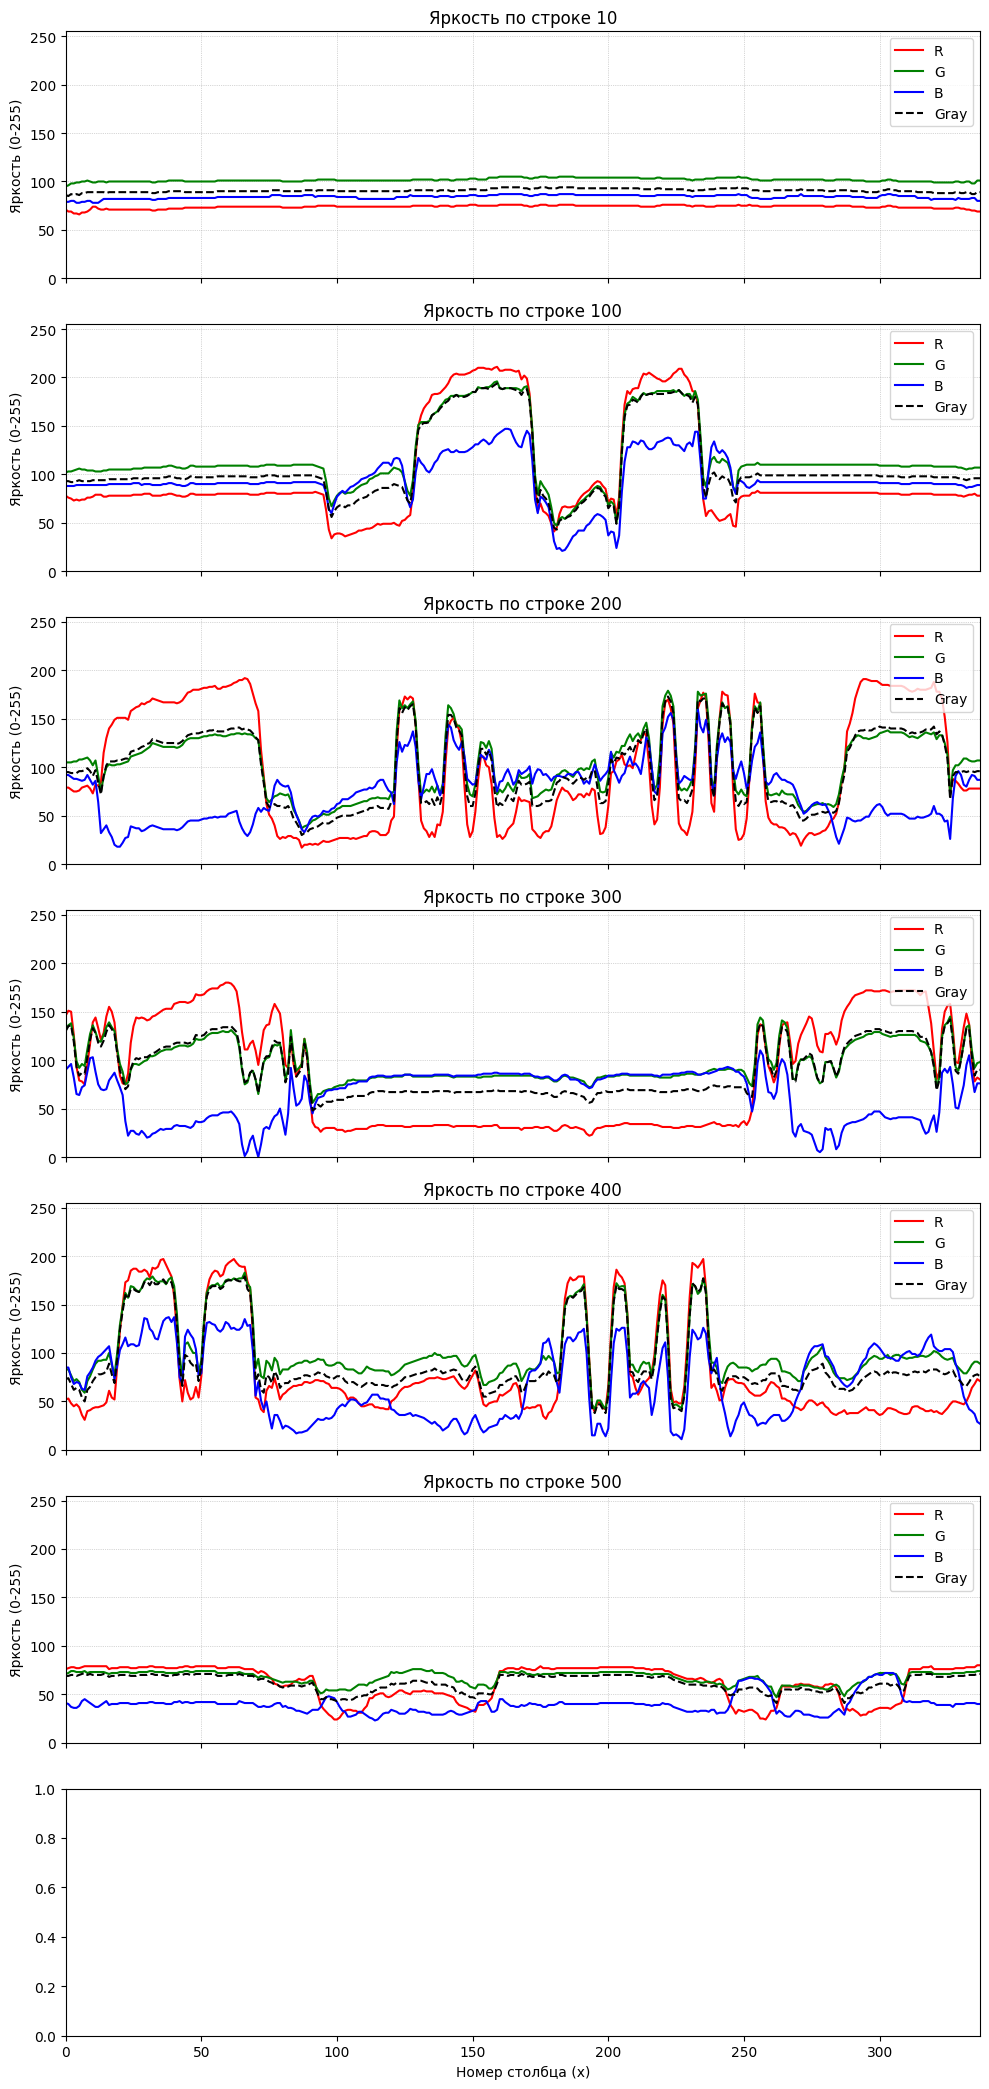

In [9]:
rows = [10, 100, 200, 300, 400, 500, 590]   # Строки для анализа яркости

fig, axes = plt.subplots(len(rows), 1, figsize=(10, 3 * len(rows)), sharex=True)
if len(rows) == 1:
    axes = [axes]
    
for ax, row in zip(axes, rows):
    if row < img.shape[0]:
        x = np.arange(img.shape[1])
        ax.plot(x, R[row, :], color='red', linewidth=1.5, label='R')
        ax.plot(x, G[row, :], color='green', linewidth=1.5, label='G')
        ax.plot(x, B[row, :], color='blue', linewidth=1.5, label='B')
        ax.plot(x, gray[row, :], color='black', linestyle='--', linewidth=1.5, label='Gray')
        ax.set_title(f'Яркость по строке {row}')
        ax.set_ylabel('Яркость (0-255)')
        ax.legend(loc='upper right')
        ax.grid(True, linestyle=':', linewidth=0.5)
        ax.set_ylim(0, 255)
        ax.set_xlim(0, img.shape[1] - 1)
        
axes[-1].set_xlabel('Номер столбца (x)')
plt.tight_layout()
plt.show()

## 6. Свёртка изображения с ядром

Реализуем операцию свёртки изображения с произвольным ядром (матрицей). Важно также обрабатывать края изображения. Рассмотрим несколько методов расширения границ при свёртке:
- **Zero-padding**: дополнение нулями (вокруг изображения)
- **Replicate** (или **edge**): повторение краевых значений пикселей
- **Reflect**: отражение изображения на границе

Функция `convolve2d` ниже выполняет свёртку для одноканального изображения с заданным ядром и методом заполнения.


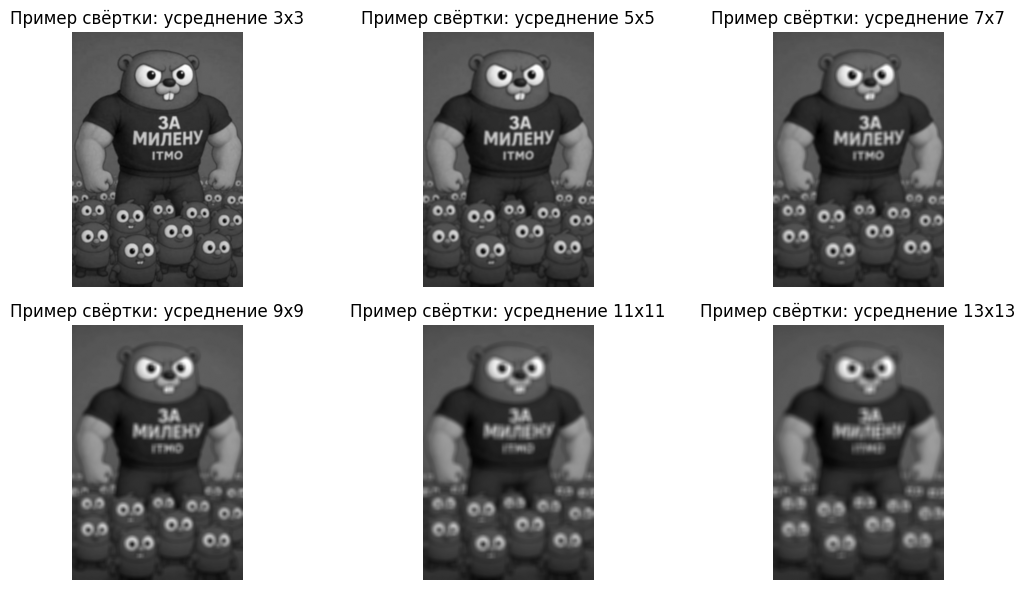

In [10]:
# Функция для реализации свёртки 2D
import math

def convolve2d(image, kernel, mode='zero'):
    # Предполагаем, что image и kernel - numpy массивы
    kh, kw = kernel.shape
    ih, iw = image.shape
    pad_h = kh // 2
    pad_w = kw // 2
    # Паддинг (расширение границ)
    if mode == 'zero':
        padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    elif mode == 'replicate':
        padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    elif mode == 'reflect':
        padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    else:
        raise ValueError("Unknown mode for padding")
    # Результирующее изображение
    result = np.zeros_like(image)
    # Перебор по пикселям
    for i in range(ih):
        for j in range(iw):
            # Окно
            window = padded[i:i+kh, j:j+kw]
            # Применяем ядро (свертку)
            result[i, j] = np.sum(window * kernel)
    return result

# Создаем сетку 2x3
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 6), sharex=False)

# Преобразуем axes в плоский массив для удобства итерации
axes_flat = axes.flatten()

for i in range(6):
    k = 2 * (i + 1) + 1  # Размер ядра свертки (3, 5, 7, 9, 11, 13)
    # Создаем ядро свертки
    ker = np.ones((k, k)) / (k * k)
    
    # Применяем свертку
    conv_example = convolve2d(gray, ker, mode='reflect')
    
    # Отображаем результат на соответствующей оси
    axes_flat[i].imshow(conv_example, cmap='gray')
    axes_flat[i].set_title(f'Пример свёртки: усреднение {k}x{k}')
    axes_flat[i].axis('off')

plt.tight_layout()
plt.show()

## 7. Фильтры

Реализуем различные фильтры, работая на изображении или его копии:


### 7a. Пороговая фильтрация (Threshold)

Этот фильтр преобразует изображение в двоичное (или двухуровневое) по заданному порогу. Все пиксели ярче порога становятся белыми (255), остальные — черными (0).


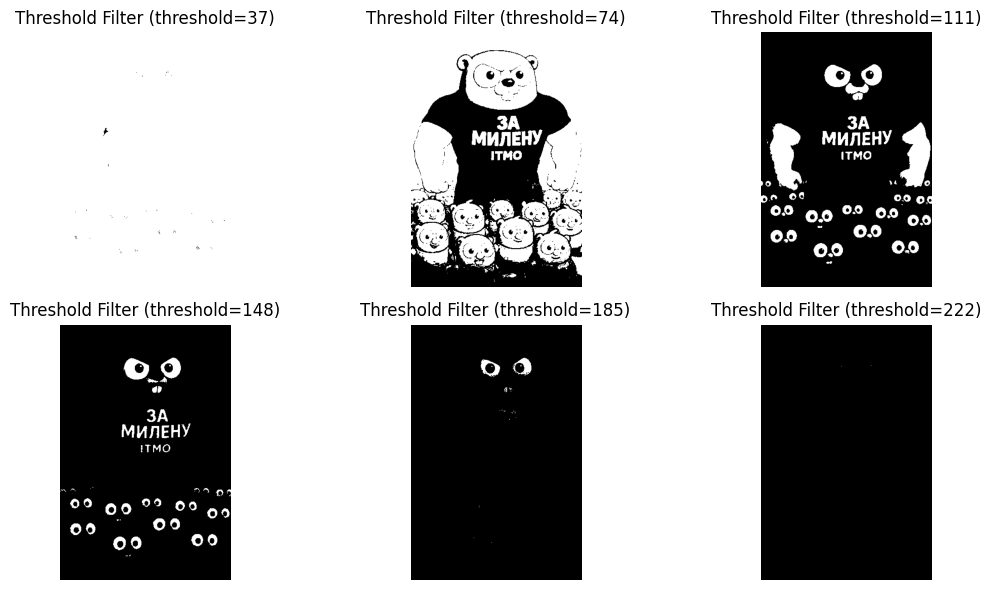

In [11]:
# Пороговая фильтрация

def threshold_filter(image, thresh):
    # Предполагаем, что вход image - одноканальное (градации серого)
    result = np.where(image > thresh, 255, 0).astype(np.uint8)
    return result

thresh_value = 128  # порог (изменяемый)
thresholded = threshold_filter(gray, thresh_value)


# Создаем сетку 2x3
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 6), sharex=False)

# Преобразуем axes в плоский массив для удобства итерации
axes_flat = axes.flatten()

for i in range(6):
    thresh_value = 37*(i+1)  # порог (изменяемый)
    thresholded = threshold_filter(gray, thresh_value)

    
    # Отображаем результат на соответствующей оси
    axes_flat[i].imshow(thresholded, cmap='gray')
    axes_flat[i].set_title(f'Threshold Filter (threshold={thresh_value})')
    axes_flat[i].axis('off')

plt.tight_layout()
plt.show()

### 7b. Медианный фильтр

Медианный фильтр заменяет каждый пиксель на медиану значений в окне. Это эффективно удаляет шум "соль и перец". Реализуем вручную.


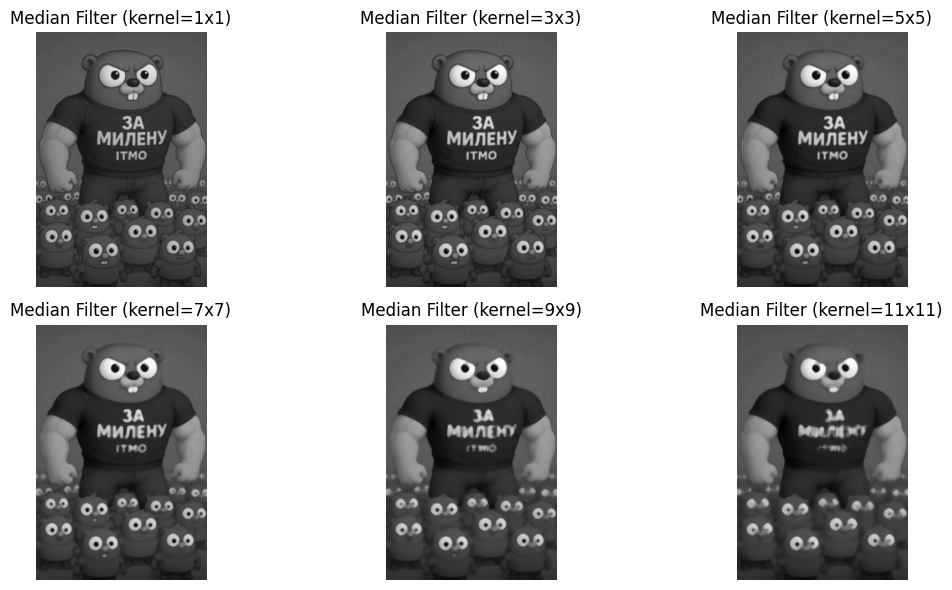

In [12]:
# Медианный фильтр (реализация вручную)

def median_filter(image, kernel_size=3):
    assert kernel_size % 2 == 1, "Kernel size must be odd."
    pad = kernel_size // 2
    # Паддинг, повторение краевых значений
    padded = np.pad(image, pad, mode='edge')
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            result[i, j] = np.median(window)
    return result

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 6), sharex=False)

# Преобразуем axes в плоский массив для удобства итерации
axes_flat = axes.flatten()

for i in range(6):
    k = 2*i + 1  # порог (изменяемый)

    median_filtered = median_filter(gray, k)
    
    # Отображаем результат на соответствующей оси
    axes_flat[i].imshow(median_filtered, cmap='gray')
    axes_flat[i].set_title(f'Median Filter (kernel={k}x{k})')
    axes_flat[i].axis('off')

plt.tight_layout()
plt.show()

### 7c. Гауссов фильтр

Гауссов фильтр применяет ядро Гаусса: значения ближе к центру взвешиваются сильнее. Параметр σ задаёт ширину гауссова колокола. Размер ядра обычно берут ~6σ+1.


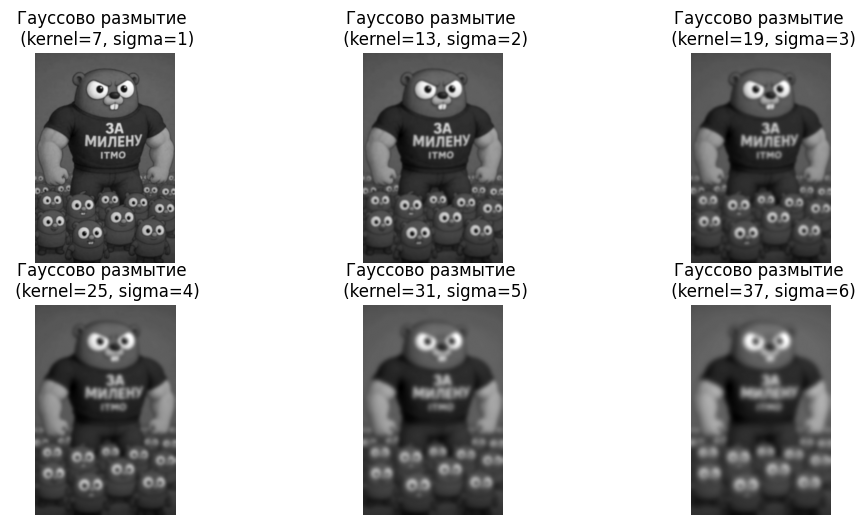

In [13]:
# Гауссов фильтр (сгенерируем ядро и применим свёртку)

def gaussian_kernel(size, sigma=1):
    assert size % 2 == 1, "Kernel size must be odd."
    ax = np.arange(-size//2 + 1., size//2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    return kernel / np.sum(kernel)

# Создаем сетку 2x3
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 6), sharex=False)

axes_flat = axes.flatten()

for i in range(6):
    sigma = i+1  
    k = 6 * (sigma) + 1  
    kernel_g = gaussian_kernel(size = k, sigma = sigma)
    blur_gauss = convolve2d(gray, kernel_g, mode='reflect')
    # Отображаем результат на соответствующей оси
    axes_flat[i].imshow(blur_gauss, cmap='gray')
    axes_flat[i].set_title(f'Гауссово размытие \n (kernel={k}, sigma={sigma})')
    axes_flat[i].axis('off')

plt.axis('off')
plt.show()

### 7d. Линейный усредняющий фильтр (Box blur)

Этот фильтр усредняет значения пикселей в окне одинакового размера (все веса равны).


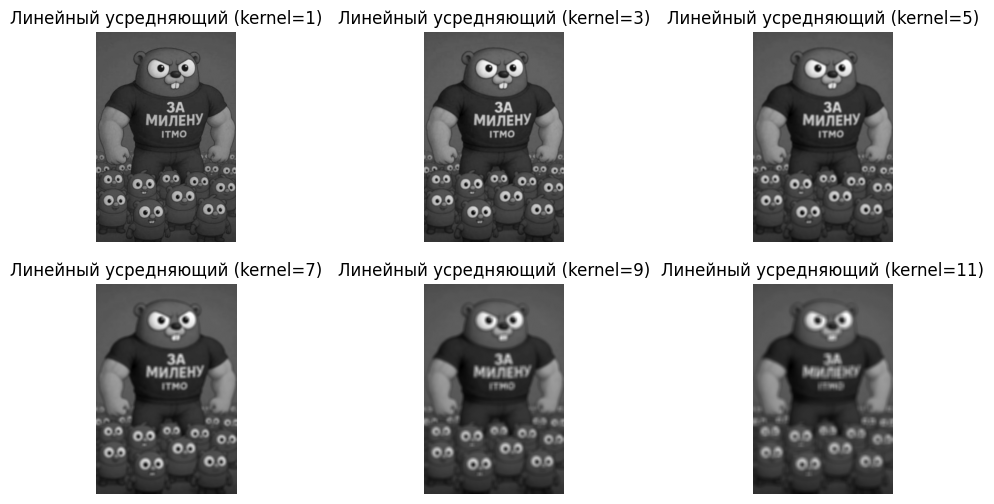

In [14]:
# Box blur (усредняющий фильтр)

def box_blur(image, kernel_size=5):
    kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size**2)
    return convolve2d(image, kernel, mode='reflect')

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 6), sharex=False)

axes_flat = axes.flatten()

for i in range(6):
    k = i*2 + 1  # Размер ядра свертки (1, 2, 3, 4, 5, 6)
    box_blured = box_blur(gray, kernel_size=k)
    # Отображаем результат на соответствующей оси
    axes_flat[i].imshow(box_blured, cmap='gray')
    axes_flat[i].set_title(f'Линейный усредняющий (kernel={k})')
    axes_flat[i].axis('off')
    
plt.axis('off')
plt.show()

### 7e. Фильтр Собеля (Sobel)

Фильтр Собеля выделяет границы, подсчитывая градиент по горизонтали и вертикали. Ядра оператора Собеля:
$$G_x = \begin{bmatrix}  -1 & 0 & 1 \\
                         -2 & 0 & 2 \\
                         -1 & 0 & 2
    \end{bmatrix}
\qquad
G_y = \begin{bmatrix} -1 & -2 & -1 \\
                        0 & 0 & 0 \\ 
                        1 & 2 & 1
    \end{bmatrix}$$

На вики было написанно что фильтр Щара дает лучшие результаты. Ядра оператора Щара:
$$S_x = \begin{bmatrix}  3 & 0 & -3 \\
                        10 & 0 & -10 \\
                         3 & 0 & -3
    \end{bmatrix}
\qquad
S_y = \begin{bmatrix}  3 & 10 & 3 \\
                       0 & 0 & 0 \\ 
                      -3 & 10 & -3
    \end{bmatrix}$$

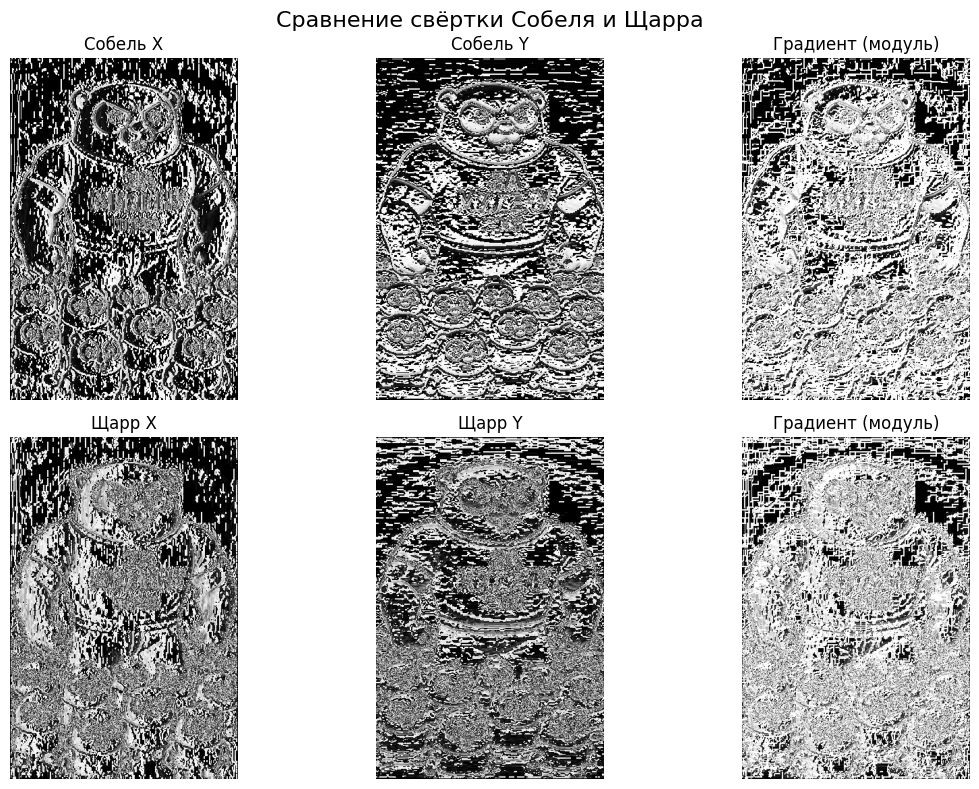

In [15]:
# Собель по x и по y
gx = np.array([[-1, 0, 1],
               [-2, 0, 2],
               [-1, 0, 1]])
gy = np.array([[-1, -2, -1],
               [ 0,  0,  0],
               [ 1,  2,  1]])

# Щарра по x и по y
sx = np.array([[3, 0, -3],
              [10, 0, -10],
               [3, 0, -3]])
sy = np.array([[3, 10, 3],
               [0, 0, 0],
             [-3, -10, -3]])

# Применяем свёртку Собеля
sobel_x = convolve2d(gray, gx, mode='reflect')
sobel_y = convolve2d(gray, gy, mode='reflect')

# Применяем свёртку Щарра
shar_x = convolve2d(gray, sx, mode='reflect')
shar_y = convolve2d(gray, sy, mode='reflect')

# Отображение результатов свёртки Собеля и Щарра

# Модуль градиентов и комбинированное изображение границ (собель)
sobel_mag = np.hypot(sobel_x.astype(float), sobel_y.astype(float))
sobel_mag = np.clip(sobel_mag, 0, 255).astype(np.uint8)

# Модуль градиентов и комбинированное изображение границ (щарра)
shar_mag = np.hypot(shar_x.astype(float), shar_y.astype(float))
shar_mag = np.clip(shar_mag, 0, 255).astype(np.uint8)

# Отображение результатов
fig, ax = plt.subplots(2, 3, figsize=(12, 8))
plt.suptitle('Сравнение свёртки Собеля и Щарра', fontsize=16)

# Собель X
ax[0, 0].imshow(sobel_x, cmap='gray')
ax[0, 0].set_title('Собель X')
ax[0, 0].axis('off')

# Собель Y
ax[0, 1].imshow(sobel_y, cmap='gray')
ax[0, 1].set_title('Собель Y')
ax[0, 1].axis('off')

# Собель (модуль)
ax[0, 2].imshow(sobel_mag, cmap='gray')
ax[0, 2].set_title('Градиент (модуль)')
ax[0, 2].axis('off')

# Щарр X
ax[1, 0].imshow(shar_x, cmap='gray')
ax[1, 0].set_title('Щарр X')
ax[1, 0].axis('off')

# Щарр Y
ax[1, 1].imshow(shar_y, cmap='gray')
ax[1, 1].set_title('Щарр Y')
ax[1, 1].axis('off')

# Щарр (модуль)
ax[1, 2].imshow(shar_mag, cmap='gray')
ax[1, 2].set_title('Градиент (модуль)')
ax[1, 2].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)  # Регулируем отступ для заголовка
plt.show()

Да, на это изображении плохо видно, в конце ноутбука приведу на другом изображении 

## 8. Алгоритм увеличения изображения

Для увеличения (масштабирования) изображения можно применять различные методы интерполяции. Например, **билинейная интерполяция** вычисляет новые значения на основе взвешенного среднего 4 ближайших пикселей. Здесь реализуем простую билинейную интерполяцию вручную.


### Математическая постановка

Пусть дана функция яркости исходного изображения $f(x, y)$, определенная на прямоугольнике $[0, l_1] \times [0, l_2]$, где $l_1$ - ширина, а $l_2$ - высота изображения в пикселях.

1.  **Коэффициенты Фурье $a_{jk}$**
    Согласно формуле (1.2) из статьи, коэффициенты двойного ряда Фурье по косинусам для функции $f(x, y)$ вычисляются как:

    $$a_{jk} = \frac{1}{l_1 l_2} \int_{0}^{l_1} \int_{0}^{l_2} f(x, y) \cos\left(\frac{\pi j x}{l_1}\right) \cos\left(\frac{\pi k y}{l_2}\right) dy dx$$

    Для дискретного изображения, где $f(x,y)$ известна в узлах сетки (пикселях), данный интеграл аппроксимируется конечной суммой. Если считать, что шаг сетки $\Delta x = 1$ и $\Delta y = 1$ (что соответствует индексам пикселей), то:

    $$a_{jk} \approx \frac{1}{l_1 l_2} \sum_{y=0}^{l_2-1} \sum_{x=0}^{l_1-1} f(x, y) \cos\left(\frac{\pi j x}{l_1}\right) \cos\left(\frac{\pi k y}{l_2}\right)$$

    Здесь $j$ и $k$ - целочисленные индексы, соответствующие пространственным частотам вдоль осей $x$ и $y$ соответственно.

2.  **Частичная сумма ряда Фурье $S_{mn}(x', y')$**
    Аппроксимация функции $f(x, y)$ частичной суммой $S_{mn}(x', y')$ ряда Фурье (формула (1.1) из статьи) используется для получения значений яркости в точках $(x', y')$ нового, увеличенного изображения:

    $$S_{mn}(x', y') = \sum_{j=-m}^{m} \sum_{k=-n}^{n} a_{jk} \cos\left(\frac{\pi j x'}{l_1}\right) \cos\left(\frac{\pi k y'}{l_2}\right)$$

    *   $(x', y')$ - координаты пикселей в **новом, увеличенном** изображении.
    *   $l_1, l_2$ - размеры **исходного** изображения. Это важно, так как периоды базисных функций $\cos\left(\frac{\pi j x'}{l_1}\right)$ и $\cos\left(\frac{\pi k y'}{l_2}\right)$ определяются именно размерами исходного изображения, на котором были вычислены коэффициенты $a_{jk}$.
    *   $m$ и $n$ - пределы суммирования, определяющие количество используемых гармоник (частот) для реконструкции.

### Реализация алгоритма в Python (функция `fourier_upscale_manual`)

Функция `fourier_upscale_manual(gray_image, scale_factor, m_coeffs_limit, n_coeffs_limit)` реализует описанный выше подход.

1.  **Подготовка и нормализация:**
    *   Входные данные:
        *   `gray_image`: Двумерный NumPy массив, представляющий изображение в градациях серого. Значения пикселей исходно в диапазоне $[0, 255]$.
        *   `scale_factor`: Коэффициент, на который необходимо увеличить изображение.
        *   `m_coeffs_limit`, `n_coeffs_limit`: Параметры $m$ и $n$ из формулы для $S_{mn}$, ограничивающие количество коэффициентов Фурье, используемых для реконструкции.
    *   Значения яркости исходного изображения $f_{xy\_orig}$ нормализуются к диапазону $[0.0, 1.0]$ путем деления на $255.0$. Это стандартная практика для численных расчетов.
    *   Определяются размеры исходного изображения: $l_{2\_orig}, l_{1\_orig} = f_{xy\_orig}.shape$.

2.  **Расчет коэффициентов Фурье $a_{jk}$ (согласно дискретной аппроксимации формулы 1.2):**
    *   Создаются сетки координат `x_coords_orig_mesh` и `y_coords_orig_mesh` для всех пикселей исходного изображения. `x_coords_orig_mesh` будет содержать $x$-координаты (от $0$ до $l_{1\_orig}-1$), а `y_coords_orig_mesh` - $y$-координаты (от $0$ до $l_{2\_orig}-1$).
    *   Инициализируется массив `a_coeffs` для хранения вычисленных коэффициентов $a_{jk}$. Его размерность $(2 \cdot n_{coeffs\_limit} + 1, 2 \cdot m_{coeffs\_limit} + 1)$ позволяет хранить коэффициенты для $k_{freq}$ от $-n_{coeffs\_limit}$ до $n_{coeffs\_limit}$ и $j_{freq}$ от $-m_{coeffs\_limit}$ до $m_{coeffs\_limit}$.
    *   Выполняется вложенный цикл по индексам частот:
        *   $k_{freq}$ пробегает значения от $-n_{coeffs\_limit}$ до $n_{coeffs\_limit}$.
        *   $j_{freq}$ пробегает значения от $-m_{coeffs\_limit}$ до $m_{coeffs\_limit}$.
    *   Внутри цикла для каждой пары $(j_{freq}, k_{freq})$:
        *   Вычисляются значения базисных косинусных функций на сетке исходного изображения:
            *   `term_x_cos` = $\cos\left(\frac{\pi \cdot j_{freq} \cdot x_{coords\_orig\_mesh}}{l_{1\_orig}}\right)$
            *   `term_y_cos` = $\cos\left(\frac{\pi \cdot k_{freq} \cdot y_{coords\_orig\_mesh}}{l_{2\_orig}}\right)$
        *   Формируется подсуммное выражение:
            *   `integrand` = $f_{xy\_orig} \cdot \text{term\_x\_cos} \cdot \text{term\_y\_cos}$
        *   Коэффициент $a_{jk}$ вычисляется как сумма всех элементов `integrand`, деленная на $(l_{1\_orig} \cdot l_{2\_orig})$:
            *   $a_{jk} = \frac{\sum \text{integrand}}{l_{1\_orig} \cdot l_{2\_orig}}$
        *   Полученное значение $a_{jk}$ сохраняется в соответствующую ячейку массива `a_coeffs`.

3.  **Реконструкция увеличенного изображения $S_{mn}(x', y')$ (согласно формуле 1.1):**
    *   Вычисляются новые размеры изображения: $l_{2\_new} = \text{int}(l_{2\_orig} \cdot \text{scale\_factor})$ и $l_{1\_new} = \text{int}(l_{1\_orig} \cdot \text{scale\_factor})$.
    *   Создаются сетки координат `x_coords_new_mesh` и `y_coords_new_mesh` для **нового, увеличенного** изображения. Эти сетки содержат координаты $(x', y')$.
    *   Инициализируется массив `reconstructed_image_f` нулями, который будет содержать значения яркости увеличенного изображения.
    *   Выполняется вложенный цикл по ранее вычисленным коэффициентам $a_{jk}$ (т.е., по $k_{freq}$ и $j_{freq}$ в тех же пределах, что и при расчете коэффициентов):
        *   Извлекается коэффициент $a_{jk} = \text{a\_coeffs}[k_{idx}, j_{idx}]$.
        *   Вычисляются значения тех же базисных косинусных функций, но теперь на координатной сетке **нового** изображения $(x_{coords\_new\_mesh}, y_{coords\_new\_mesh})$. **Ключевой момент**: в знаменателях аргументов косинусов по-прежнему используются $l_{1\_orig}$ и $l_{2\_orig}$ (размеры исходного изображения):
            *   `term_x_cos_new` = $\cos\left(\frac{\pi \cdot j_{freq} \cdot x_{coords\_new\_mesh}}{l_{1\_orig}}\right)$
            *   `term_y_cos_new` = $\cos\left(\frac{\pi \cdot k_{freq} \cdot y_{coords\_new\_mesh}}{l_{2\_orig}}\right)$
        *   Текущее слагаемое ряда Фурье $a_{jk} \cdot \text{term\_x\_cos\_new} \cdot \text{term\_y\_cos\_new}$ прибавляется к `reconstructed_image_f`. Таким образом, `reconstructed_image_f` накапливает сумму ряда.

4.  **Денормализация и приведение к типу `uint8`:**
    *   Полученные значения яркости в `reconstructed_image_f` умножаются на $255.0$ для возврата к исходному диапазону.
    *   Применяется функция `np.clip` для ограничения значений диапазоном $[0, 255]$, чтобы избежать артефактов при преобразовании типа.
    *   Изображение преобразуется к типу `np.uint8`.
    *   Результат `upscaled_image` возвращается функцией.

### Анализ результатов и выводы

*(Здесь студенту следует описать полученные результаты, сравнить с другими методами интерполяции (например, билинейной), обсудить влияние параметров `m_coeffs_limit` и `n_coeffs_limit` на качество и время выполнения, а также упомянуть эффект Гиббса, если он наблюдается.)*

Например:
*   С увеличением `m_coeffs_limit` и `n_coeffs_limit` качество аппроксимации улучшается, изображение становится более детализированным. Однако это значительно увеличивает время вычислений.
*   При малых значениях `m_coeffs_limit` и `n_coeffs_limit` изображение получается сильно размытым, так как используются только низкочастотные компоненты.
*   Можно наблюдать эффект Гиббса в виде ряби или осцилляций вблизи резких перепадов яркости, особенно при использовании большого числа коэффициентов. Это характерное свойство аппроксимации разрывных функций рядами Фурье.
*   Сравнение с билинейной интерполяцией показывает, что метод на основе рядов Фурье может давать более "гладкие" результаты, но при этом склонен к появлению специфических артефактов (эффект Гиббса) и значительно более требователен к вычислительным ресурсам при прямой реализации.
Use code with caution.
Markdown


In [36]:

from tqdm import tqdm # For progress bars, useful for long computations

import numpy as np
import cv2 # Только для загрузки/сохранения и начального преобразования в серое, если нужно
import matplotlib.pyplot as plt
from tqdm import tqdm # Для индикаторов прогресса

def fourier_upscale_manual_corrected(gray_image, scale_factor, m_coeffs_limit=None, n_coeffs_limit=None):
    """
    Увеличивает изображение с использованием аппроксимации рядом Фурье,
    как описано в статье (формулы 1.1 и 1.2), с ИСПРАВЛЕННЫМ масштабированием
    при реконструкции.

    Args:
        gray_image (np.ndarray): Входное одноканальное изображение (градации серого).
                                 Значения пикселей предполагаются в диапазоне [0, 255].
        scale_factor (float): Коэффициент увеличения.
        m_coeffs_limit (int, optional): Максимальный индекс 'm' для суммирования по j (ширина).
                                       j будет пробегать значения от -m_coeffs_limit до m_coeffs_limit.
                                       Если None, используется l1_orig // 4.
        n_coeffs_limit (int, optional): Максимальный индекс 'n' для суммирования по k (высота).
                                       k будет пробегать значения от -n_coeffs_limit до n_coeffs_limit.
                                       Если None, используется l2_orig // 4.
    Returns:
        np.ndarray: Увеличенное изображение.
    """
    if not isinstance(gray_image, np.ndarray) or gray_image.ndim != 2:
        raise ValueError("Входное изображение должно быть 2D NumPy массивом (градации серого).")

    # 1. Нормализуем изображение к диапазону [0, 1]
    f_xy_orig = gray_image.astype(np.float32) / 255.0
    l2_orig, l1_orig = f_xy_orig.shape  # l2_orig = высота, l1_orig = ширина

    # 2. Определяем пределы для коэффициентов Фурье (m и n из S_mn)
    if m_coeffs_limit is None:
        m_coeffs_limit = l1_orig // 4 
    if n_coeffs_limit is None:
        n_coeffs_limit = l2_orig // 4 
    
    print(f"Исходные размеры: ширина (l1)={l1_orig}, высота (l2)={l2_orig}")
    print(f"Пределы для коэффициентов: m_limit={m_coeffs_limit}, n_limit={n_coeffs_limit}")
    num_total_coeffs = (2 * m_coeffs_limit + 1) * (2 * n_coeffs_limit + 1)
    print(f"Общее количество коэффициентов a_jk для расчета: {num_total_coeffs}")

    # 3. Расчет коэффициентов Фурье a_jk (Формула 1.2)
    y_coords_orig_mesh, x_coords_orig_mesh = np.mgrid[0:l2_orig, 0:l1_orig]
    a_coeffs = np.zeros((2 * n_coeffs_limit + 1, 2 * m_coeffs_limit + 1), dtype=np.float32) # Коэффициенты будут вещественными

    print("Расчет коэффициентов a_jk...")
    for k_idx, k_freq in enumerate(tqdm(range(-n_coeffs_limit, n_coeffs_limit + 1), desc="k_freq (расчет коэфф.)")):
        for j_idx, j_freq in enumerate(range(-m_coeffs_limit, m_coeffs_limit + 1)):
            term_x_cos = np.cos(np.pi * j_freq * x_coords_orig_mesh / l1_orig)
            term_y_cos = np.cos(np.pi * k_freq * y_coords_orig_mesh / l2_orig)
            
            integrand = f_xy_orig * term_x_cos * term_y_cos
            
            a_jk = np.sum(integrand) / (l1_orig * l2_orig)
            a_coeffs[k_idx, j_idx] = a_jk
            
    # 4. Реконструкция увеличенного изображения S_mn(x', y') (Формула 1.1)
    # Округляем до ближайшего целого для размеров нового изображения
    l2_new = int(round(l2_orig * scale_factor))
    l1_new = int(round(l1_orig * scale_factor))
    print(f"Новые размеры: ширина={l1_new}, высота={l2_new}")
        # ... после вычисления l1_new, l2_new
    print(f"Debug: l1_orig={l1_orig}, l2_orig={l2_orig}, scale_factor={scale_factor}")
    print(f"Debug: l1_new={l1_new}, l2_new={l2_new}")
    print(f"Debug: denominator_x_new={denominator_x_new}, denominator_y_new={denominator_y_new}")

    # Проверим максимальное значение нормализованной координаты
    max_norm_x = np.max(x_coords_new_mesh / denominator_x_new)
    max_norm_y = np.max(y_coords_new_mesh / denominator_y_new)
    print(f"Debug: Max normalized x' = {max_norm_x:.4f} (должно быть близко к 1)")
    print(f"Debug: Max normalized y' = {max_norm_y:.4f} (должно быть близко к 1)")
        
    y_coords_new_mesh, x_coords_new_mesh = np.mgrid[0:l2_new, 0:l1_new]
    reconstructed_image_f = np.zeros((l2_new, l1_new), dtype=np.float32)

    print("Реконструкция изображения S_mn(x', y')...")

    # ----- ИСПРАВЛЕНИЕ ЗДЕСЬ -----
    # Эффективные "периоды" для косинусов на новой сетке.
    # Аргумент косинуса должен быть pi * j * (x_prime / scale_factor) / l1_orig
    # = pi * j * x_prime / (l1_orig * scale_factor)
    # Аналогично для y.
    # Это гарантирует, что одна "копия" функции Фурье растянется на все новое изображение.
    
    # Используем float для знаменателей, чтобы избежать целочисленного деления раньше времени
    denominator_x_new = float(l1_orig * scale_factor)
    denominator_y_new = float(l2_orig * scale_factor)

    # Предотвращение деления на ноль, если scale_factor или размеры малы (маловероятно, но безопасно)
    if denominator_x_new == 0: denominator_x_new = 1e-9 
    if denominator_y_new == 0: denominator_y_new = 1e-9
        # ... после вычисления l1_new, l2_new
    print(f"Debug: l1_orig={l1_orig}, l2_orig={l2_orig}, scale_factor={scale_factor}")
    print(f"Debug: l1_new={l1_new}, l2_new={l2_new}")
    print(f"Debug: denominator_x_new={denominator_x_new}, denominator_y_new={denominator_y_new}")

    # Проверим максимальное значение нормализованной координаты
    max_norm_x = np.max(x_coords_new_mesh / denominator_x_new)
    max_norm_y = np.max(y_coords_new_mesh / denominator_y_new)
    print(f"Debug: Max normalized x' = {max_norm_x:.4f} (должно быть близко к 1)")
    print(f"Debug: Max normalized y' = {max_norm_y:.4f} (должно быть близко к 1)")

    for k_idx, k_freq in enumerate(tqdm(range(-n_coeffs_limit, n_coeffs_limit + 1), desc="k_freq (реконструкция)")):
        for j_idx, j_freq in enumerate(range(-m_coeffs_limit, m_coeffs_limit + 1)):
            a_jk = a_coeffs[k_idx, j_idx] # Коэффициенты уже вещественные
                
            term_x_cos_new = np.cos(np.pi * j_freq * x_coords_new_mesh / denominator_x_new)
            term_y_cos_new = np.cos(np.pi * k_freq * y_coords_new_mesh / denominator_y_new)
                # Суммируем по всем коэффициентам        
            reconstructed_image_f += a_jk * term_x_cos_new * term_y_cos_new
            
    # 5. Денормализация и приведение к типу uint8
    upscaled_image = np.clip(reconstructed_image_f * 255.0, 0, 255).astype(np.uint8)
    
    return upscaled_image

Уменьшаем изображение до 200x300 для демонстрации...
Размер изображения для апскейлинга: (300, 200)
Используемые m_limit_demo = 25, n_limit_demo = 37
Исходные размеры: ширина (l1)=200, высота (l2)=300
Пределы для коэффициентов: m_limit=25, n_limit=37
Общее количество коэффициентов a_jk для расчета: 3825
Расчет коэффициентов a_jk...


k_freq: 100%|██████████| 75/75 [00:03<00:00, 19.78it/s]


Новые размеры: ширина=400, высота=600
Реконструкция изображения S_mn(x', y')...


k_freq_recon: 100%|██████████| 75/75 [00:28<00:00,  2.61it/s]


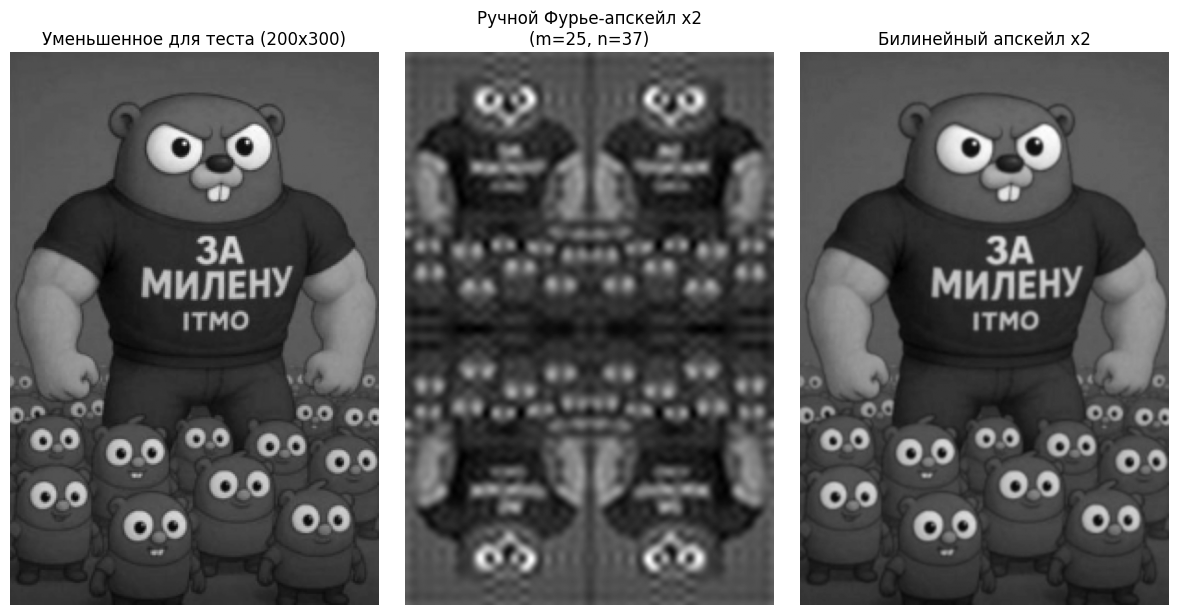

In [37]:
h_orig, w_orig = gray.shape
demo_size_w = 200 # Желаемый размер для быстрой демонстрации
demo_size_h = int(h_orig * demo_size_w / w_orig)

if w_orig > demo_size_w:
    print(f"Уменьшаем изображение до {demo_size_w}x{demo_size_h} для демонстрации...")
    gray_small = cv2.resize(gray, (demo_size_w, demo_size_h), interpolation=cv2.INTER_AREA)
else:
    gray_small = gray.copy()

print(f"Размер изображения для апскейлинга: {gray_small.shape}")

# Параметры m и n (пределы для j и k)
# Для лучшего качества m_coeffs_limit и n_coeffs_limit должны быть больше,
# например, gray_small.shape[1] // 2 и gray_small.shape[0] // 2
# или даже gray_small.shape[1] и gray_small.shape[0] (как в статье m=n=100 для 100x100)
# Но для скорости возьмем небольшие значения:
# Если хотите качество как в статье, попробуйте:
m_limit_demo = gray_small.shape[1] // 8  # Для демонстрации
n_limit_demo = gray_small.shape[0] // 8  # Для демонстрации
# Но это будет ОЧЕНЬ ДОЛГО без оптимизаций или FFT.

print(f"Используемые m_limit_demo = {m_limit_demo}, n_limit_demo = {n_limit_demo}")

upscaled_manual = fourier_upscale_manual(gray_small, 
                                         scale_factor=scale, 
                                         m_coeffs_limit=m_limit_demo, 
                                         n_coeffs_limit=n_limit_demo)

# Для сравнения, стандартное билинейное увеличение
upscaled_bilinear = cv2.resize(gray_small, 
                               (gray_small.shape[1] * scale, gray_small.shape[0] * scale), 
                               interpolation=cv2.INTER_LINEAR)

# Отображение результатов
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(gray_small, cmap='gray')
plt.title(f'Уменьшенное для теста ({gray_small.shape[1]}x{gray_small.shape[0]})')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(upscaled_manual, cmap='gray')
plt.title(f'Ручной Фурье-апскейл x{scale}\n(m={m_limit_demo}, n={n_limit_demo})')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(upscaled_bilinear, cmap='gray')
plt.title(f'Билинейный апскейл x{scale}')
plt.axis('off')

plt.tight_layout()
plt.show()

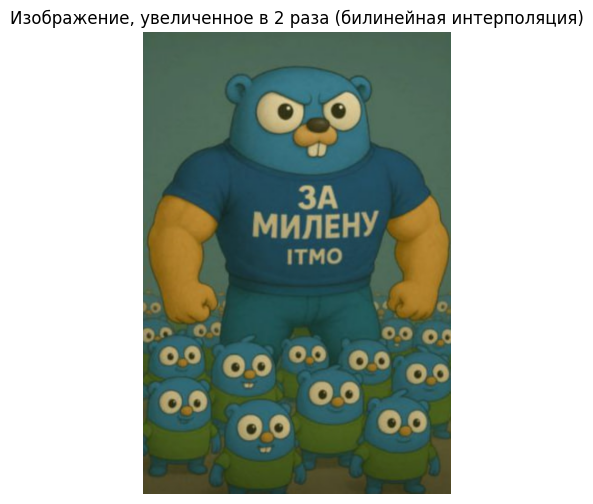

In [19]:
# Функция для билинейной интерполяции увеличения изображения

def upscale_bilinear(image, scale_factor):
    # Если изображение цветное, обрабатываем каждый канал отдельно
    if image.ndim == 3:
        channels = []
        for c in range(image.shape[2]):
            channels.append(upscale_bilinear(image[:,:,c], scale_factor))
        return np.stack(channels, axis=2)
    h, w = image.shape
    new_h = int(h * scale_factor)
    new_w = int(w * scale_factor)
    result = np.zeros((new_h, new_w), dtype=image.dtype)
    for i in range(new_h):
        for j in range(new_w):
            # Найдем положение в исходном изображении
            x = i / scale_factor
            y = j / scale_factor
            x0 = int(np.floor(x))
            y0 = int(np.floor(y))
            x1 = min(x0 + 1, h - 1)
            y1 = min(y0 + 1, w - 1)
            dx = x - x0
            dy = y - y0
            # Взвешенное среднее (билинейная интерполяция)
            pixel = (image[x0, y0] * (1 - dx) * (1 - dy) +
                     image[x1, y0] * dx * (1 - dy) +
                     image[x0, y1] * (1 - dx) * dy +
                     image[x1, y1] * dx * dy)
            result[i, j] = pixel
    return result

# Применим увеличение
scale = 2  # коэффициент увеличения
upscaled_image = upscale_bilinear(img, scale)
plt.figure(figsize=(6,6))
plt.imshow(upscaled_image)
plt.title(f'Изображение, увеличенное в {scale} раза (билинейная интерполяция)')
plt.axis('off')
plt.show()

## 9. Спектр Фурье изображения

Рассмотрим двумерное преобразование Фурье изображения. Вычислим быстрое преобразование Фурье (FFT) и отобразим спектр амплитуд (часто в логарифмическом масштабе). Также можно модифицировать спектр, например, подавить некоторые частоты и выполнить обратное преобразование.


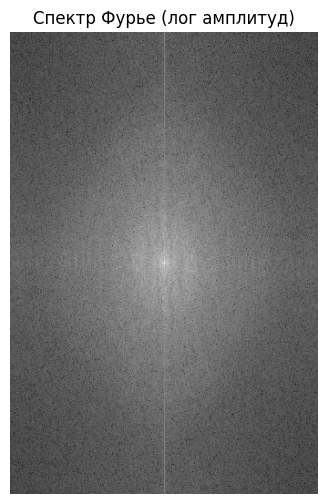

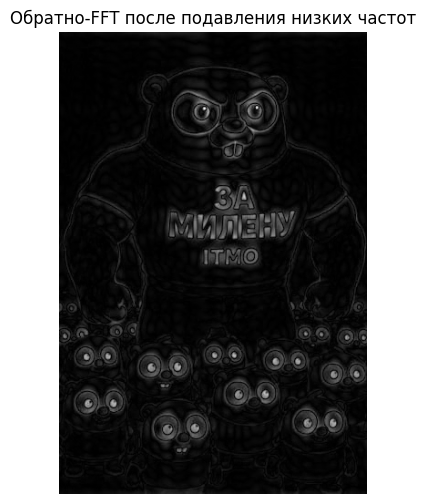

In [20]:
# Вычислим двумерное FFT для серого изображения
f = np.fft.fft2(gray)
fshift = np.fft.fftshift(f)
# Модуль спектра
magnitude_spectrum = 20*np.log(np.abs(fshift) + 1)  # добавляем 1 чтобы избежать log(0)

plt.figure(figsize=(6,6))
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Спектр Фурье (лог амплитуд)')
plt.axis('off')
plt.show()

# Пример фильтрации в частотной области: подавление низких частот (high-pass)
rows, cols = gray.shape
crow, ccol = rows//2, cols//2
# Создадим копию спектра и обнулим центральные низкочастотные компоненты
fshift_hp = fshift.copy()
cutoff = 20  # радиус вырезания низких частот
fshift_hp[crow-cutoff:crow+cutoff, ccol-cutoff:ccol+cutoff] = 0

# Обратное преобразование Фурье
f_ishift = np.fft.ifftshift(fshift_hp)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

plt.figure(figsize=(6,6))
plt.imshow(img_back, cmap='gray')
plt.title('Обратно-FFT после подавления низких частот')
plt.axis('off')
plt.show()

## 10. Низкочастотная и высокочастотная фильтрация

Низкочастотные фильтры размывают изображение (удаляют шум и мелкие детали), высокочастотные выделяют границы и детали. Например, можно получить изображение с усиленными краями, вычитая низкочастотное из оригинала (или суммируя с высоким).


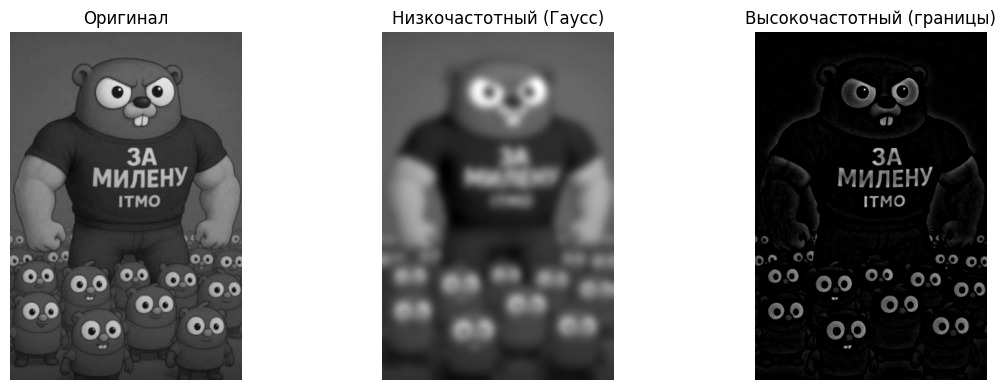

In [21]:
# Лоу-пасс: усреднение (или Гаусс) - мы уже получили blur_gauss
# Хай-пасс: оригинал минус размытие
high_pass = cv2.subtract(gray.astype(int), blur_gauss.astype(int))
high_pass = np.clip(high_pass, 0, 255).astype(np.uint8)
fig, ax = plt.subplots(1,3, figsize=(12,4))
ax[0].imshow(gray, cmap='gray'); ax[0].set_title('Оригинал'); ax[0].axis('off')
ax[1].imshow(blur_gauss, cmap='gray'); ax[1].set_title('Низкочастотный (Гаусс)'); ax[1].axis('off')
ax[2].imshow(high_pass, cmap='gray'); ax[2].set_title('Высокочастотный (границы)'); ax[2].axis('off')
plt.tight_layout()
plt.show()